# MNIST Classification with CNN

In this notebook, we classify the MNIST dataset using a convolutional neural network

## Hyperparameters

In [1]:
batch_size: int = 64
learning_rate: float = 0.05
n_epochs: int = 5

log_interval: int = 10

## Loading the datasets

In [2]:
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

train_loader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

test_loader = DataLoader(
    dataset=test_data
)

## Plotting some examples

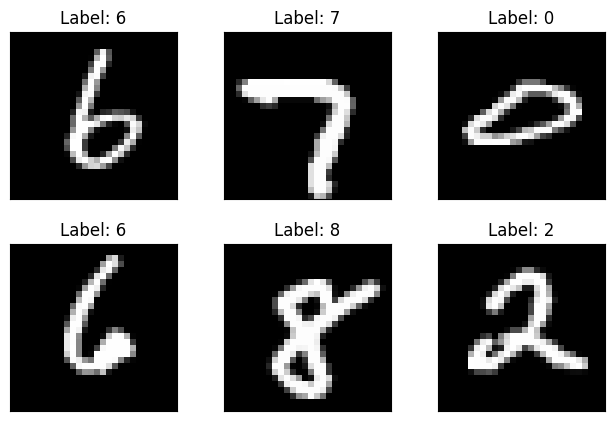

In [3]:
import matplotlib.pyplot as plt

# shape of example_data: (batch_size, 1, 28, 28)
# shape of example_targets: (batch_size)
batch_idx, (example_data, example_targets) = next(enumerate(train_loader))

fig = plt.figure()

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray')
    plt.title(f'Label: {example_targets[i]}')
    plt.xticks([])
    plt.yticks([])

## Definition of the CNN

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(
        self, 
        x: torch.tensor # (batch_size, 1, 28, 28)
    ) -> torch.tensor: # (batch_size, 10)
        x = self.pool(F.relu(self.conv1(x))) # (batch_size, 10, 12, 12)
        x = self.pool(F.relu(self.conv2(x))) # (batch_size, 20, 4, 4)
        x = torch.flatten(x, 1) # (64, 320)
        x = self.fc1(x) # (batch_size, 50)
        x = self.fc2(x) # (batch_size, 10)
        return F.softmax(x, dim=1)

## Setup for training

In [5]:
import torch.optim as optim

network = Net()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(network.parameters(), lr=learning_rate)

train_losses: list[float] = []
train_counter: list[int] = []
test_losses: list[float] = []
test_counter: list[int]  =  [i * len(train_loader.dataset) for i in range(n_epochs + 1)]

In [6]:
def train(epoch: int):
    network.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % log_interval == 0:
            print(f'Train Epoch {epoch}: [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item()}')
            train_losses.append(loss.item())
            train_counter.append((batch_idx * batch_size) + ((epoch - 1) * len(train_loader.dataset)))

In [7]:
def test():
    network.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = network(data)
            test_loss += criterion(output, target).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum()
        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)

        print(f'\nTest set: Avg. loss: {test_loss}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset)}%)\n')

In [8]:
test()
for epoch in range(1, n_epochs + 1):
    train(epoch)
    test()


Test set: Avg. loss: 2.3026472188711167, Accuracy: 1111/10000 (11.109999656677246%)

Train Epoch 1: [0/60000] Loss: 2.303925037384033
Train Epoch 1: [640/60000] Loss: 2.303068161010742
Train Epoch 1: [1280/60000] Loss: 2.3036246299743652
Train Epoch 1: [1920/60000] Loss: 2.302485466003418
Train Epoch 1: [2560/60000] Loss: 2.3039565086364746
Train Epoch 1: [3200/60000] Loss: 2.3002591133117676
Train Epoch 1: [3840/60000] Loss: 2.30277419090271
Train Epoch 1: [4480/60000] Loss: 2.300436496734619
Train Epoch 1: [5120/60000] Loss: 2.301828622817993
Train Epoch 1: [5760/60000] Loss: 2.299208641052246
Train Epoch 1: [6400/60000] Loss: 2.3014748096466064
Train Epoch 1: [7040/60000] Loss: 2.3016397953033447
Train Epoch 1: [7680/60000] Loss: 2.3016445636749268
Train Epoch 1: [8320/60000] Loss: 2.3037569522857666
Train Epoch 1: [8960/60000] Loss: 2.3032331466674805
Train Epoch 1: [9600/60000] Loss: 2.2996666431427
Train Epoch 1: [10240/60000] Loss: 2.2997922897338867
Train Epoch 1: [10880/60000

Text(0, 0.5, 'CrossEntropyLoss')

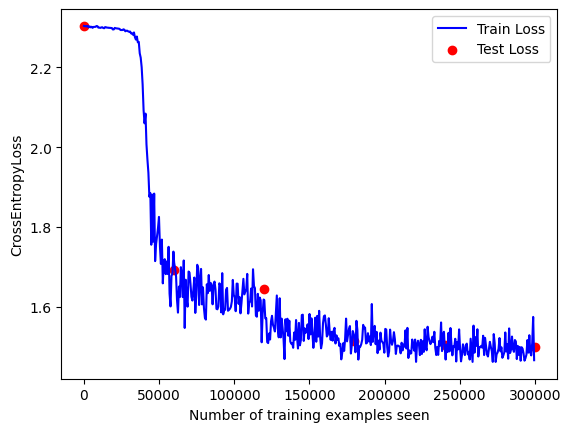

In [9]:
fig = plt.figure()
plt.plot(train_counter, train_losses, color='blue')
plt.scatter(test_counter, test_losses, color='red')
plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
plt.xlabel('Number of training examples seen')
plt.ylabel('CrossEntropyLoss')

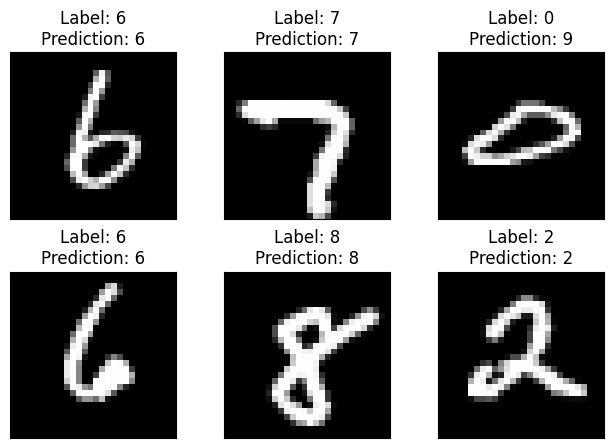

In [10]:
with torch.no_grad():
    output = network(example_data)

    fig = plt.figure()
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.tight_layout()
        plt.imshow(example_data[i][0], cmap='gray')
        plt.title(f'Label: {example_targets[i]}\nPrediction: {output.data.max(1, keepdim=True)[1][i].item()}')
        plt.xticks([])
        plt.yticks([])